# Calendar Heatmap

This section showcases the calendar heatmap. It contains examples of how to create calendar heatmaps using the [datachart.charts.CalendarHeatmap](../../../references/charts/#datachart.charts.CalendarHeatmap) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-calendar-heatmap), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the calendar heatmaps are created using the `CalendarHeatmap` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import CalendarHeatmap

## Calendar Heatmap Input Attributes

The `CalendarHeatmap` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains the dated values. For a single calendar, `data` is a dictionary with a `date` list of temporal objects — `datetime.date`, `datetime.datetime`, `numpy.datetime64`, or pandas `Timestamp` — and a `value` list with one number per date. For multiple calendars, `data` is a list of such dictionaries.

```python
CalendarHeatmap(
    data={                                              # The dated values (or list of dicts for multiple calendars)
        "date": List[Union[date, datetime]],            # One temporal object per day; date strings are never parsed
        "value": List[Union[int, float, None]],         # The value of each day; None leaves the day blank
    },
    style={                                             # The style of the calendar (optional)
        "plot_calendar_heatmap_cmap":            Optional[Union[str, List[str]]], # The colormap (palette name or list of hex colors); None takes the heatmap colormap
        "plot_calendar_heatmap_alpha":           Optional[float],    # The alpha of the day cells (how visible they are)
        "plot_calendar_heatmap_font_size":       Optional[Union[int, float, str]], # The font size of the cell values
        "plot_calendar_heatmap_font_color":      Optional[str],      # The font color of the cell values (hex color code)
        "plot_calendar_heatmap_font_style":      Optional[FONT_STYLE], # The font style of the cell values (normal, italic, etc.)
        "plot_calendar_heatmap_font_weight":     Optional[FONT_WEIGHT], # The font weight of the cell values (normal, bold, etc.)
        "plot_calendar_heatmap_edge_width":      Optional[float],    # The width of the borders between the day cells (0 draws none)
        "plot_calendar_heatmap_edge_color":      Optional[str],      # The color of the borders between the day cells (hex color code)
        "plot_calendar_heatmap_month_line_width": Optional[float],   # The width of the separators between the months (0 draws none)
        "plot_calendar_heatmap_month_line_color": Optional[str],     # The color of the separators between the months (hex color code)
        "plot_calendar_heatmap_week_start":      Optional[WEEKDAY],  # The weekday of the top row, the default of week_start
    },
    subtitle=Optional[str],                             # The subtitle of the calendar (or list for multiple calendars)
    title=Optional[str],                                # The title of the chart

    year=Optional[int],                                 # The one year to draw; every year of the data otherwise
    week_start=Optional[WEEKDAY],                       # The weekday of the top row ("monday", "sunday")
    show_month_labels=Optional[bool],                   # Whether to label the months along the top
    show_weekday_labels=Optional[bool],                 # Whether to label every other weekday along the left

    figsize=Optional[Tuple[float, float]],              # The figure size in inches
    aspect_ratio=Optional[str],                         # The aspect ratio of the cells ("equal" by default, "auto")
    max_cols=Optional[int],                             # Maximum number of calendars per row (1 by default)

    show_colorbars=Optional[bool],                      # Whether to show the colorbar
    show_values=Optional[bool],                         # Whether to write the values into the cells
    value_format=Optional[str],                         # The format of the cell values
    colorbar={                                          # The colorbar configuration (or list for multiple calendars)
        "label": Optional[str],                         # The caption beside the bar
        "location": Optional[COLORBAR_LOCATION],        # The chart edge the bar sits on
        "format": Optional[str],                        # The format of the bar's tick labels
        "ticks": Optional[List[float]],                 # Explicit tick positions on the bar
    },

    norm=Optional[str],                                 # The value normalization ("linear", "log", "symlog", "asinh", "logit"; or list for multiple calendars)
    vmin=Optional[float],                               # The value mapped to the first color (or list for multiple calendars)
    vmax=Optional[float],                               # The value mapped to the last color (or list for multiple calendars)

    texts=Optional[List[TextSettingAttrs]],             # Text annotations in cell coordinates (week along x, weekday row along y)
)
```

For more details, see the [datachart.charts.CalendarHeatmap](../../../references/charts/#datachart.charts.CalendarHeatmap) function.

## Basics

The examples in this guide share one dataset: the number of cyclists counted each day of 2024 by an automatic counter on a city cycle path. The counts are illustrative, drawn from a seeded generator in a hidden cell with the rhythm such a counter records: commuter traffic on weekdays, quieter weekends, a summer peak, rainy days that halve the count, and a week in November when the counter was down. `cyclists` holds the dates and the counts.

In [2]:
import datetime
import numpy as np

rng = np.random.RandomState(2024)


def daily_cyclists(year, seed):
    """Illustrative daily cyclist counts: commuter weekdays, a summer peak, rain."""
    rng = np.random.RandomState(seed)
    first = datetime.date(year, 1, 1)
    n_days = (datetime.date(year + 1, 1, 1) - first).days
    dates, counts = [], []
    for i in range(n_days):
        day = first + datetime.timedelta(days=i)
        season = 1 + 0.6 * np.sin((i / n_days - 0.2) * 2 * np.pi)
        base = 900 if day.weekday() < 5 else 450
        count = base * season * rng.normal(1.0, 0.12)
        # a rainy day halves the traffic
        if rng.rand() < 0.15:
            count *= 0.5
        dates.append(day)
        counts.append(int(round(count)))
    return dates, counts


DATES, COUNTS = daily_cyclists(2024, seed=7)
# the counter was down for a week in November: those days are missing
outage = {datetime.date(2024, 11, 11) + datetime.timedelta(days=i) for i in range(7)}
cyclists = {
    "date": [d for d in DATES if d not in outage],
    "value": [c for d, c in zip(DATES, COUNTS) if d not in outage],
}

The data is a dictionary: `date` is a list of `datetime.date` objects, one per day, and `value` the count of that day. Every date appears once; a day that is not in the list — the outage week here — is drawn as a blank cell.

In [3]:
list(zip(cyclists["date"][:3], cyclists["value"][:3]))

[(datetime.date(2024, 1, 1), 465),
 (datetime.date(2024, 1, 2), 368),
 (datetime.date(2024, 1, 3), 355)]

**Basic example.** Only the `data` argument is required to draw the calendar heatmap. Each column is a week and each row a weekday, Monday at the top; the calendar spans the months that hold data, the whole year here; every cell is colored by its value, the months are separated by a stepped line and labelled along the top, and every other weekday is labelled on the left. The cells stay square, so the figure is wide and short by default.

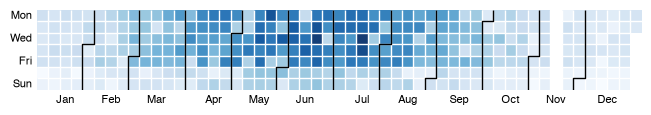

In [4]:
CalendarHeatmap(
    # add the data to the chart
    data=cyclists
).show()

## Customizing the Calendar Heatmap

Every customization is either a keyword argument of `CalendarHeatmap` or a `plot_calendar_heatmap_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title                                 | `title`                                                                 | [Title and figure size](#title-and-figure-size) |
| resize the figure                           | `figsize`                                                               | [Title and figure size](#title-and-figure-size) |
| stretch the cells to the figure             | `aspect_ratio`                                                          | [Title and figure size](#title-and-figure-size) |
| start the week on Sunday                    | `week_start`                                                            | [Week start](#week-start) |
| hide the month or weekday labels            | `show_month_labels`, `show_weekday_labels`                              | [Month and weekday labels](#month-and-weekday-labels) |
| show the colorbar                           | `show_colorbars`, `colorbar`                                            | [Colorbar and cell values](#colorbar-and-cell-values) |
| write the values into the cells             | `show_values`, `value_format`                                           | [Colorbar and cell values](#colorbar-and-cell-values) |
| change the colormap or transparency         | `style={"plot_calendar_heatmap_cmap": ..., "plot_calendar_heatmap_alpha": ...}` | [Calendar style](#calendar-style) |
| style the cell values                       | `style={"plot_calendar_heatmap_font_size": ..., ...}`                   | [Calendar style](#calendar-style) |
| change the cell borders or month separators | `style={"plot_calendar_heatmap_edge_width": ..., "plot_calendar_heatmap_month_line_color": ...}` | [Calendar style](#calendar-style) |
| fix the value range of the colormap         | `vmin`, `vmax`                                                          | [Normalization](#normalization) |
| spread skewed values over the colormap      | `norm`                                                                  | [Normalization](#normalization) |
| highlight one series, mute the rest         | not supported                                                           | [Emphasis](#emphasis) |
| draw several years                          | `data` spanning several years, `year`                                   | [One calendar per year](#one-calendar-per-year) |
| compare several series                      | `data` as a list of dicts, `subtitle`, `max_cols`                       | [Multiple datasets](#multiple-datasets) |
| place a calendar beside other charts        | `Grid`                                                                  | [Composing calendar heatmaps](#composing-calendar-heatmaps) |
| save the chart to a file                    | `save_figure`                                                           | [Saving the Chart as an Image](#saving-the-chart-as-an-image) |

The full list of style attributes is in the [datachart.typings.CalendarHeatmapStyleAttrs](../../../references/typings/#datachart.typings.CalendarHeatmapStyleAttrs) type; the full list of parameters is in the [datachart.charts.CalendarHeatmap](../../../references/charts/#datachart.charts.CalendarHeatmap) reference.

### Title and figure size

To add the chart title, add the `title` attribute. A calendar names its own axes — the months and the weekdays — so there are no axis labels to set.

To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains some of the predefined figure sizes. By default the cells are square and the figure wide and short; a wider figure gives larger cells. To stretch the cells to whatever figure you set instead, add the `aspect_ratio` attribute with [datachart.constants.ASPECT_RATIO.AUTO](../../../references/constants/#datachart.constants.ASPECT_RATIO).

In [5]:
from datachart.constants import FIG_SIZE, ASPECT_RATIO

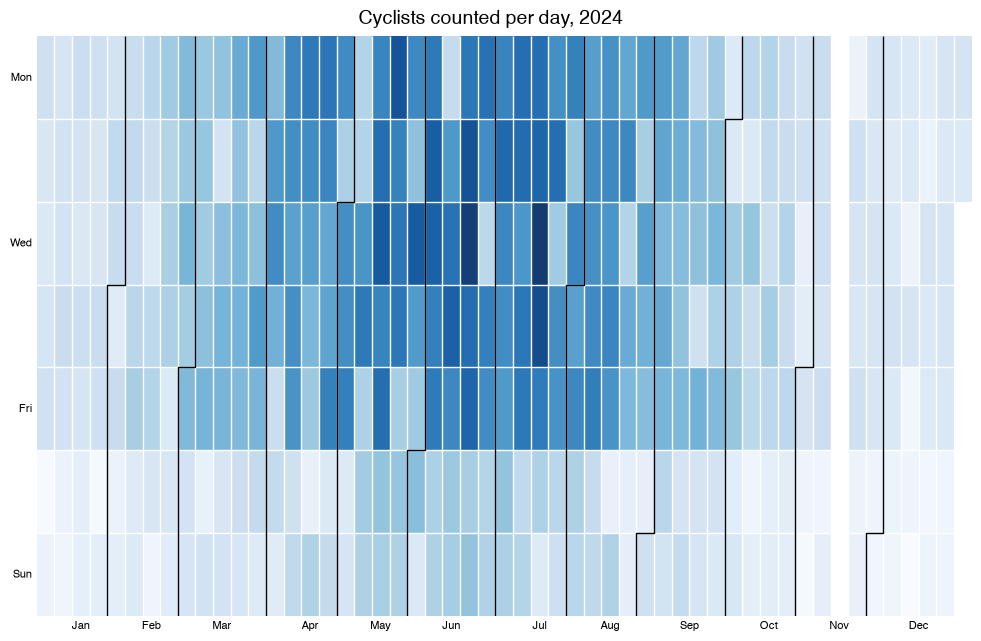

In [6]:
CalendarHeatmap(
    data=cyclists,
    # add the title
    title="Cyclists counted per day, 2024",
    # add to determine the figure size
    figsize=FIG_SIZE.A4_LANDSCAPE,
    # stretch the cells to fill it
    aspect_ratio=ASPECT_RATIO.AUTO,
).show()

### Week start

The weeks run from Monday to Sunday by default. To start them on Sunday, as American calendars do, add the `week_start` attribute with a [datachart.constants.WEEKDAY](../../../references/constants/#datachart.constants.WEEKDAY) constant. The default comes from the theme's `plot_calendar_heatmap_week_start` attribute, so it can be set once for every chart through the [config](../../styling/themes/#what-a-theme-controls).

In [7]:
from datachart.constants import WEEKDAY

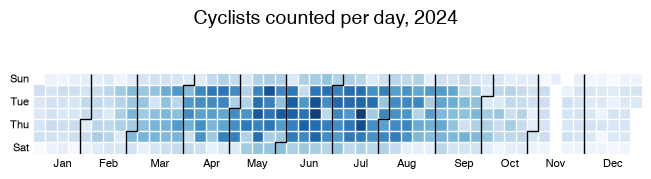

In [8]:
CalendarHeatmap(
    data=cyclists,
    # start the weeks on Sunday
    week_start=WEEKDAY.SUNDAY,
    title="Cyclists counted per day, 2024",
).show()

### Month and weekday labels

The months are labelled along the top, each over the middle of its weeks, and every other weekday along the left. To hide them, add the `show_month_labels` and `show_weekday_labels` attributes; the month separators stay, so the months still read.

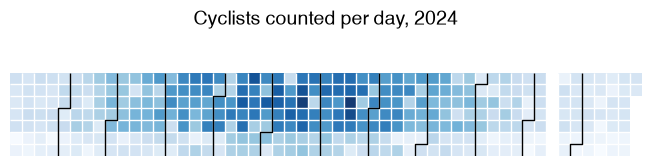

In [9]:
CalendarHeatmap(
    data=cyclists,
    # hide the axis labels
    show_month_labels=False,
    show_weekday_labels=False,
    title="Cyclists counted per day, 2024",
).show()

### Colorbar and cell values

A calendar on its own shows which days are busier and which are quieter, not by how much. Two attributes add the numbers back: `show_colorbars` draws the colorbar that maps the colors to values, and `show_values` writes every value into its cell. On dark cells the value is written in white automatically, so it stays legible across the whole colormap.

The colorbar takes a `colorbar` setting — a [datachart.typings.ColorbarSettingAttrs](../../../references/typings/#datachart.typings.ColorbarSettingAttrs) dictionary — with its `label`, its `location` (a [datachart.constants.COLORBAR_LOCATION](../../../references/constants/#datachart.constants.COLORBAR_LOCATION) constant), the `format` of its tick labels, and explicit `ticks`. The `value_format` attribute formats the cell values: use one of the [datachart.constants.VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constants or any `"{x:.1f}"`, `"{:.1f}"`, or `"%g"` style string. The cells are small, so the values suit a short span drawn wide; the example writes the first ten weeks of the year, and the calendar spans only the months they fall in.

In [10]:
from datachart.constants import COLORBAR_LOCATION, VALUE_FORMAT

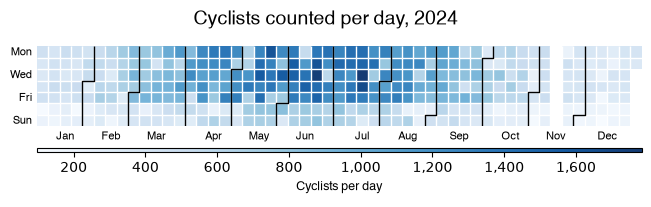

In [11]:
CalendarHeatmap(
    data=cyclists,
    title="Cyclists counted per day, 2024",
    # add to show the colorbar
    show_colorbars=True,
    colorbar={
        "label": "Cyclists per day",
        "location": COLORBAR_LOCATION.BOTTOM,
        "format": VALUE_FORMAT.THOUSANDS,
    },
).show()

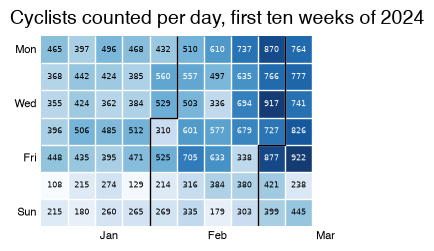

In [12]:
# the first ten weeks, wide enough to read the values
first_weeks = {
    "date": cyclists["date"][:70],
    "value": cyclists["value"][:70],
}

CalendarHeatmap(
    data=first_weeks,
    # add to write the values into the cells
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
    title="Cyclists counted per day, first ten weeks of 2024",
    figsize=(12, 2.4),
).show()

### Calendar style

To change the calendar style, add the `style` attribute with the corresponding attributes. The supported attributes are shown in the [datachart.typings.CalendarHeatmapStyleAttrs](../../../references/typings/#datachart.typings.CalendarHeatmapStyleAttrs) type, which contains the following attributes:

| Attribute                                  | Description |
| :----------------------------------------- | :---------- |
| `plot_calendar_heatmap_cmap`               | The colormap of the day cells: a palette name, a single color, a list of hex colors, or a matplotlib colormap. `None` takes the theme's heatmap colormap. |
| `plot_calendar_heatmap_alpha`              | The alpha (transparency) of the day cells. |
| `plot_calendar_heatmap_font_size`          | The font size of the cell values. |
| `plot_calendar_heatmap_font_color`         | The font color of the cell values. |
| `plot_calendar_heatmap_font_style`         | The font style of the cell values (normal, italic). |
| `plot_calendar_heatmap_font_weight`        | The font weight of the cell values (normal, bold). |
| `plot_calendar_heatmap_edge_width`         | The width of the borders drawn between the day cells (0 draws none). |
| `plot_calendar_heatmap_edge_color`         | The color of the borders drawn between the day cells. |
| `plot_calendar_heatmap_month_line_width`   | The width of the separators drawn between the months (0 draws none). |
| `plot_calendar_heatmap_month_line_color`   | The color of the separators drawn between the months. `None` takes the theme's heatmap frame color. |
| `plot_calendar_heatmap_week_start`         | The weekday of the top row, the default of `week_start`. |

The colormap can be any of the [datachart.constants.COLORS](../../../references/constants/#datachart.constants.COLORS) constants or a list of hex colors, as in the [colormaps guide](../../styling/colormaps/). The borders between the cells are white by default, standing in for the gaps of a printed calendar; a dark color turns them into a grid.

In [13]:
from datachart.constants import COLORS

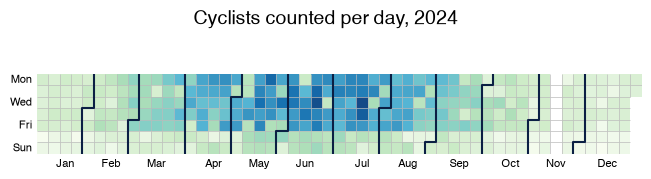

In [14]:
CalendarHeatmap(
    data=cyclists,
    # define the style of the calendar
    style={
        "plot_calendar_heatmap_cmap": COLORS.GnBu,
        "plot_calendar_heatmap_edge_width": 0.5,
        "plot_calendar_heatmap_edge_color": "#BBBBBB",
        "plot_calendar_heatmap_month_line_width": 1.5,
        "plot_calendar_heatmap_month_line_color": "#0B1F44",
    },
    title="Cyclists counted per day, 2024",
).show()

### Normalization

The colors of a calendar come from a two-step mapping: the values are first normalized to the 0–1 range, then each normalized value picks its color from the colormap. Both steps can be adjusted, exactly as on the [heatmap](../heatmap/#normalization).

**Value range.** By default the smallest value maps to the first color and the largest to the last. The `vmin` and `vmax` attributes pin those endpoints instead — to compare calendars drawn separately on one scale, or to keep a few extreme days from washing out the rest.

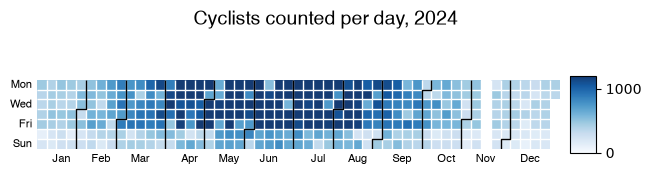

In [15]:
CalendarHeatmap(
    data=cyclists,
    # pin the value range: the busiest days saturate, the rest spread out
    vmin=0,
    vmax=1200,
    title="Cyclists counted per day, 2024",
    show_colorbars=True,
).show()

**Normalization.** The `norm` attribute changes how the values are spread over the 0–1 range: `"linear"` (the default), `"log"`, `"symlog"`, `"asinh"`, or `"logit"`, as the [datachart.constants.NORMALIZE](../../../references/constants/#datachart.constants.NORMALIZE) constants name them. A skewed series — a few very busy days above many quiet ones — reads better on `"log"` or `"asinh"`, which give the low counts more of the colormap.

In [16]:
from datachart.constants import NORMALIZE

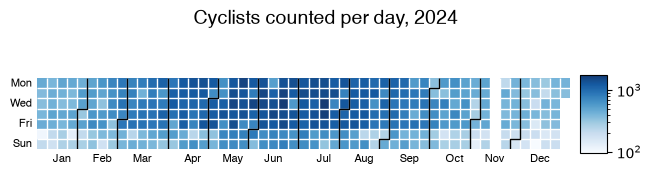

In [17]:
CalendarHeatmap(
    data=cyclists,
    # spread the quiet days over more of the colormap
    norm=NORMALIZE.LOG,
    title="Cyclists counted per day, 2024",
    show_colorbars=True,
).show()

### Emphasis

The other charts accept an `emphasis` attribute that highlights one series and mutes the rest. The calendar heatmap does not: like the heatmap it is a single raster layer, not a set of series, so there is nothing to bring forward or push back, and `CalendarHeatmap` raises a `ValueError` if `emphasis` is passed. To draw attention to part of a calendar, pin the value range or pick a colormap that saturates at the level of interest, or annotate a day with `texts`; see the [highlighting guide](../../styling/highlighting/) for the charts that take `emphasis`.

## Multiple Calendar Heatmaps

### One calendar per year

Data spanning several years draws one calendar per year, in year order, each subtitled by its year. The years share one value range, so the same count takes the same color in every calendar; `vmin` and `vmax` still pin the range when set. The `title` is positioned to be global for all calendars, and `max_cols` limits the number of calendars per row — one by default, so the years stack.

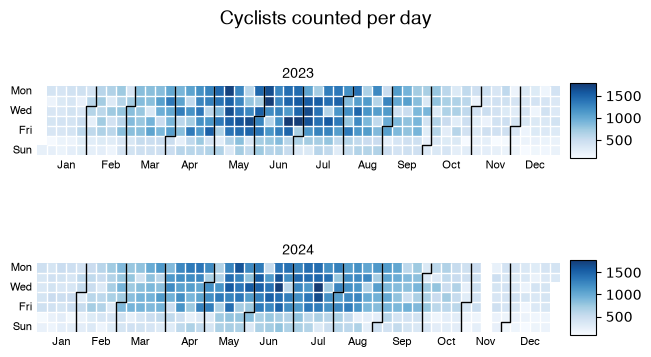

In [18]:
DATES_2023, COUNTS_2023 = daily_cyclists(2023, seed=3)

two_years = {
    "date": DATES_2023 + cyclists["date"],
    "value": COUNTS_2023 + cyclists["value"],
}

CalendarHeatmap(
    # data from two years: one calendar per year
    data=two_years,
    title="Cyclists counted per day",
    show_colorbars=True,
).show()

### The year filter

To draw one year of a longer series, add the `year` attribute. A year without any data raises a `ValueError`.

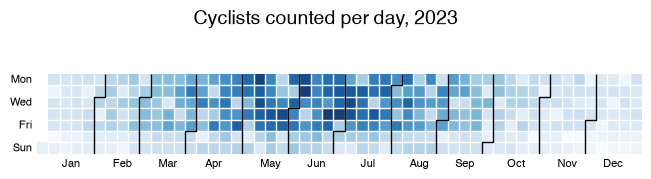

In [19]:
CalendarHeatmap(
    data=two_years,
    # keep the one year
    year=2023,
    title="Cyclists counted per day, 2023",
).show()

### Multiple datasets

To compare several series, pass a list of dictionaries to the `data` argument. Each is drawn in its own calendar with the `subtitle` at the top; a dataset spanning several years still splits into one calendar per year, named by the subtitle and the year. Per-calendar attributes like `style`, `norm`, `vmin`, `vmax`, and `colorbar` can be lists with one entry per dataset. The example compares the counter with a second one on a quieter path.

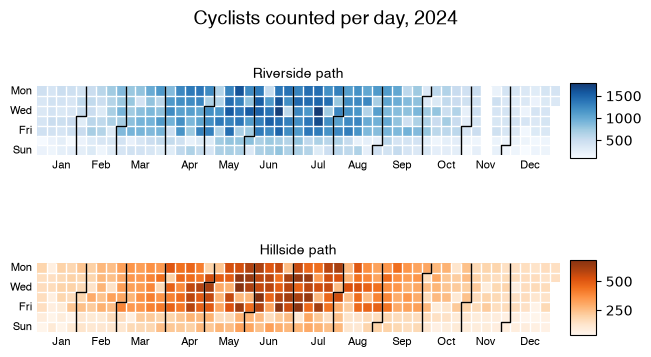

In [20]:
DATES_B, COUNTS_B = daily_cyclists(2024, seed=11)
quieter = {"date": DATES_B, "value": [int(c * 0.4) for c in COUNTS_B]}

CalendarHeatmap(
    # use a list of dicts to define multiple calendars
    data=[cyclists, quieter],
    # add a subtitle to each calendar
    subtitle=["Riverside path", "Hillside path"],
    # style can be a list (one per calendar) or a single dict
    style=[None, {"plot_calendar_heatmap_cmap": COLORS.Oranges}],
    title="Cyclists counted per day, 2024",
    show_colorbars=True,
).show()

### Composing calendar heatmaps

A calendar owns its axes — the weeks and weekdays are not a coordinate space another chart shares — so [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) rejects a calendar figure. [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges it beside other charts; a multi-year calendar keeps its stack of years in its cell. The example sets the calendar over a bar chart of the monthly totals.

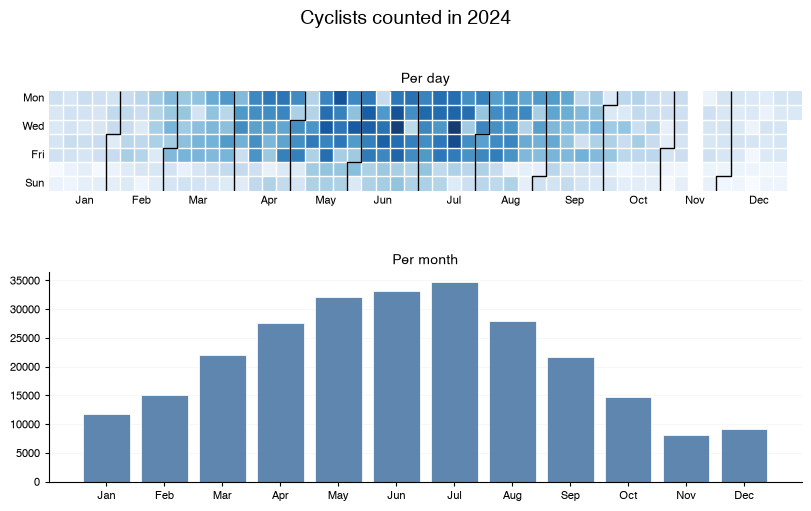

In [21]:
from datachart.charts import BarChart
from datachart.utils import Grid

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly = [
    {"label": name, "y": sum(c for d, c in zip(cyclists["date"], cyclists["value"]) if d.month == m)}
    for m, name in enumerate(MONTHS, start=1)
]

calendar = CalendarHeatmap(data=cyclists, title="Per day")
totals = BarChart(data=monthly, title="Per month", figsize=(6.4, 2.4))

Grid([[calendar], [totals]], title="Cyclists counted in 2024", figsize=(8, 5)).show()

### Themes

A theme sets the colormap, the fonts, and the cell values default of every chart at once; the calendar's colormap follows the theme's heatmap colormap unless `plot_calendar_heatmap_cmap` sets its own. See the [Theme Gallery](../../styling/theme-gallery/) for the whole suite under each theme. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) as the [Themes](../../styling/themes/) guide shows.

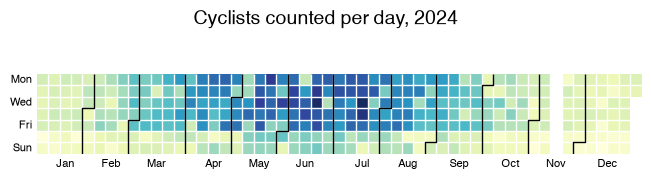

In [22]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.INK)
figure = CalendarHeatmap(data=cyclists, title="Cyclists counted per day, 2024")
config.set_theme(THEME.DEFAULT)
figure.show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [23]:
from datachart.utils import save_figure

figure = CalendarHeatmap(data=cyclists, title="Cyclists counted per day, 2024")
save_figure(figure, "./fig_calendar_heatmap.png", dpi=300)

['./fig_calendar_heatmap.png']

The figure should be saved in the current working directory.

## Real-World Examples

The following examples put the features above to work. Each one states what it shows; the data is illustrative, drawn from a seeded generator in a hidden cell.

### Example 1: Commit Activity (Skewed Counts, Sunday Weeks, No Colorbar)

`contributions` holds the number of commits on each day of 2025 by one illustrative developer: most weekdays see a few commits, weekends rarely any, and two release weeks in March and September see a burst of them. The calendar is laid out like the GitHub contributions graph: the weeks start on Sunday, the colormap is GitHub's green scale passed as a list of hex colors, and there is no colorbar — the calendar is read by pattern, not by value. The release weeks would drown the everyday commits on a linear colormap, so `NORMALIZE.ASINH` spreads the low counts over the greens.

In [24]:
rng = np.random.RandomState(3)
YEAR = 2025
first_day = datetime.date(YEAR, 1, 1)
n_days = (datetime.date(YEAR + 1, 1, 1) - first_day).days

commit_dates, commit_counts = [], []
for i in range(n_days):
    day = first_day + datetime.timedelta(days=i)
    if day.weekday() < 5:
        commits = int(rng.poisson(2.5)) if rng.rand() < 0.7 else 0
        # release weeks in March and September
        if day.isocalendar()[1] in (11, 37):
            commits += int(rng.poisson(12))
    else:
        commits = int(rng.poisson(0.8)) if rng.rand() < 0.3 else 0
    commit_dates.append(day)
    commit_counts.append(commits)

contributions = {"date": commit_dates, "value": commit_counts}

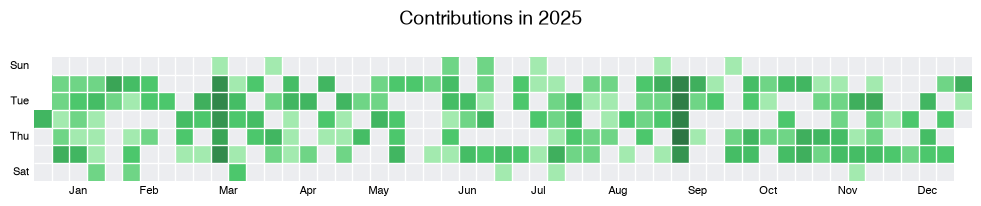

In [25]:
# the green scale of the GitHub contributions graph, from no commits to many
GITHUB_GREENS = ["#ebedf0", "#9be9a8", "#40c463", "#30a14e", "#216e39"]

CalendarHeatmap(
    data=contributions,
    style={
        "plot_calendar_heatmap_cmap": GITHUB_GREENS,
        # the graph has no month separators, only the gaps between the squares
        "plot_calendar_heatmap_month_line_width": 0,
    },
    # spread the everyday counts over the colormap despite the release weeks
    norm=NORMALIZE.ASINH,
    week_start=WEEKDAY.SUNDAY,
    title=f"Contributions in {YEAR}",
    figsize=(9.7, 2.0),
).show()

### Example 2: Daily Rainfall over Three Years (Multi-Year, Shared Range, Blank Dry Days)

`rainfall` holds the illustrative daily precipitation, in millimetres, at a station with wet winters and dry summers over 2022–2024. A dry day has no value at all rather than a zero, so it is drawn blank and the wet days stand out; the three calendars share one value range and one colorbar scale, so a downpour looks the same whichever year it fell in. The `colorbar` names the unit and formats its ticks.

In [26]:
rng = np.random.RandomState(12)
rain_dates, rain_mm = [], []
for year in (2022, 2023, 2024):
    first = datetime.date(year, 1, 1)
    n_days = (datetime.date(year + 1, 1, 1) - first).days
    for i in range(n_days):
        day = first + datetime.timedelta(days=i)
        # wet winters, dry summers
        wet_chance = 0.45 - 0.35 * np.sin((i / n_days - 0.25) * 2 * np.pi)
        if rng.rand() < wet_chance:
            rain_dates.append(day)
            rain_mm.append(round(float(rng.gamma(2.0, 4.0)), 1))

rainfall = {"date": rain_dates, "value": rain_mm}

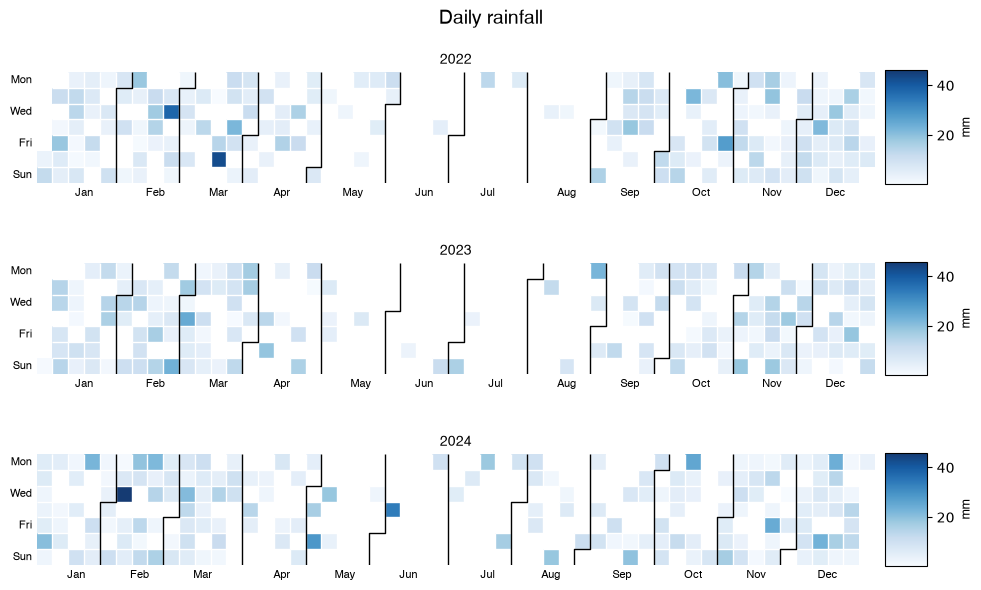

In [27]:
CalendarHeatmap(
    data=rainfall,
    style={"plot_calendar_heatmap_cmap": COLORS.Blues},
    title="Daily rainfall",
    show_colorbars=True,
    colorbar={"label": "mm", "format": VALUE_FORMAT.INTEGER},
    figsize=(9.7, 6.0),
).show()

### Example 3: Store Footfall with a Note (Values, Annotations, and a Pinned Range)

`footfall` holds the illustrative number of visitors to a shop over the last quarter of 2024: busy Saturdays, a closed Sunday every week, and the pre-Christmas rush. The values are written into the cells, the range is pinned so the December peak saturates while the ordinary weeks keep their contrast, and a `texts` annotation marks the day of the winter sale. Annotations sit in cell coordinates: the week column along `x` and the weekday row along `y`, both counted from the top-left cell of the drawn range — here the week of 1 October, since a calendar spans only the months that hold data.

In [28]:
rng = np.random.RandomState(9)
foot_dates, foot_counts = [], []
day = datetime.date(2024, 10, 1)
while day.year == 2024:
    if day.weekday() < 6:
        base = 320 if day.weekday() == 5 else 180
        # the run-up to Christmas
        if datetime.date(2024, 12, 9) <= day <= datetime.date(2024, 12, 24):
            base *= 1.8
        foot_dates.append(day)
        foot_counts.append(int(rng.normal(base, base * 0.1)))
    day += datetime.timedelta(days=1)

footfall = {"date": foot_dates, "value": foot_counts}

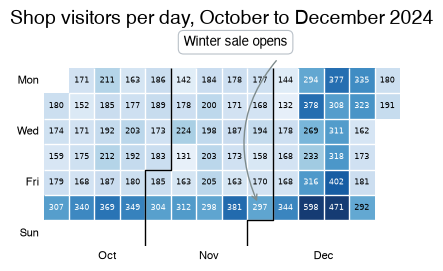

In [29]:
from datachart.constants import ARROW_STYLE

# the winter sale started on Saturday, 30 November: its week column, counted
# from the week of 1 October (the first drawn month), and its weekday row
first_drawn = datetime.date(2024, 10, 1)
sale = datetime.date(2024, 11, 30)
sale_week = (first_drawn.weekday() + (sale - first_drawn).days) // 7
sale_row = sale.weekday()

CalendarHeatmap(
    data=footfall,
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
    vmin=100,
    vmax=450,
    texts={
        "text": "Winter sale opens",
        "x": sale_week - 3,
        "y": -1.5,
        "target": (sale_week, sale_row),
        "style": {"plot_text_arrow_style": ARROW_STYLE.CURVE_ARROW},
    },
    title="Shop visitors per day, October to December 2024",
    figsize=(12, 2.6),
).show()